In [1]:
# ===================================================
# Fine-Tuning Results Analysis Notebook
# Purpose: Analyze GA fine tuning results
# ===================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
import os
import json
import pandas as pd


results_dir = Path().resolve() / "runs"


records = []


for file in os.listdir(results_dir):
    if file.endswith(".json"):
        file_path = os.path.join(results_dir, file)
        with open(file_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        
        h = data.get("hparams", {})
        m = data.get("metrics", {})
        d = data.get("diagnostics", {})
        meta = data.get("meta", {})

        record = {
            "candidate_id": data.get("candidate_id"),
            "seed": data.get("seed"),
            "algo": data.get("algo"),

            
            "best_final": m.get("best_final"),
            "auc_best": m.get("auc_best"),
            "auc_best_norm": m.get("auc_best_norm"),
            "runtime_sec": m.get("runtime_sec"),
            "evals_total": m.get("evals_total"),
            "budget_triggered": m.get("budget_triggered"),

            
            "delta_abs_best": d.get("best", {}).get("delta_abs"),
            "delta_rel_best": d.get("best", {}).get("delta_rel"),


            "lambda_in": h.get("lambda_in"),
            "lambda_out": h.get("lambda_out"),
            "sel_mutation": h.get("sel_mutation"),
            "tail_mutation": h.get("tail_mutation"),
            "tourn_size": h.get("tourn_size"),
            "popsize": h.get("popsize"),
            "generations": h.get("generations"),

            
            "L_used": meta.get("L_used"),
            "runtime_sec_meta": meta.get("runtime_sec"),
        }

        records.append(record)


df_finetuning = pd.DataFrame(records)


df_finetuning = df_finetuning.sort_values(by=["candidate_id", "seed"]).reset_index(drop=True)


print(f"✅ {len(df_finetuning)} resultados cargados.")
display(df_finetuning.head())


✅ 1100 resultados cargados.


,candidate_id,seed,algo,best_final,auc_best,auc_best_norm,runtime_sec,evals_total,budget_triggered,delta_abs_best,delta_rel_best,lambda_in,lambda_out,sel_mutation,tail_mutation,tourn_size,popsize,generations,L_used,runtime_sec_meta
0,2838,101,macro_micro,438.65,43855.400,438.55400,166.841599,2122,False,1.50,0.003431,0.05,0.2,0.015,0.005,5.0,22,100,33,166.841599
1,2838,202,macro_micro,438.65,43856.075,438.56075,165.740630,2122,False,1.95,0.004465,0.05,0.2,0.015,0.005,5.0,22,100,33,165.740630
2,2838,303,macro_micro,438.65,43857.125,438.57125,165.037164,2122,False,1.95,0.004465,0.05,0.2,0.015,0.005,5.0,22,100,33,165.037164
3,2838,404,macro_micro,438.65,43853.525,438.53525,162.798241,2122,False,1.65,0.003776,0.05,0.2,0.015,0.005,5.0,22,100,33,162.798241
4,2838,505,macro_micro,438.65,43846.550,438.46550,168.770823,2122,False,1.50,0.003431,0.05,0.2,0.015,0.005,5.0,22,100,33,168.770823


In [3]:
import pandas as pd
import numpy as np
from scipy.stats import rankdata, kruskal

# Métrica base
metric = "auc_best_norm"


groups = [g[metric].values for _, g in df_finetuning.groupby("candidate_id")]
kruskal_result = kruskal(*groups)

print(f"Kruskal–Wallis H = {kruskal_result.statistic:.3f}, p = {kruskal_result.pvalue:.3e}")


Kruskal–Wallis H = 660.658, p = 6.912e-84


In [4]:
# Añade los ranks globales (rangos de menor a mayor)
df_finetuning["rank"] = rankdata(df_finetuning[metric])

# Promedio de rangos por candidato
rank_means = (
    df_finetuning.groupby("candidate_id")["rank"]
    .agg(["mean", "std", "count"])
    .sort_values("mean", ascending=False)
)

rank_means["rank_mean_diff"] = rank_means["mean"] - rank_means["mean"].mean()
display(rank_means.head(10))


,mean,std,count,rank_mean_diff
candidate_id,,,,
17925,956.000000,106.288758,11,405.500000
32397,926.136364,143.794661,11,375.636364
45387,896.454545,155.277567,11,345.954545
35409,896.181818,248.008193,11,345.681818
60009,889.681818,147.371346,11,339.181818
44253,871.227273,145.034714,11,320.727273
23574,858.636364,173.477533,11,308.136364
41279,857.272727,183.194345,11,306.772727
4947,849.272727,173.808711,11,298.772727


C:\Users\57305\AppData\Local\Temp\ipykernel_36324\759400793.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


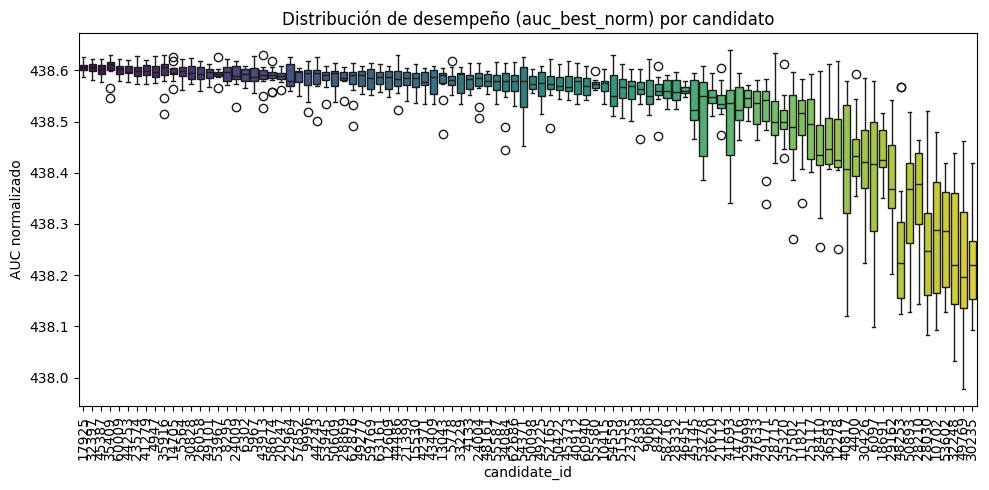

In [5]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df_finetuning,
    x="candidate_id",
    y="auc_best_norm",
    order=rank_means.index,  # ordenados por rango promedio
    palette="viridis"
)
plt.xticks(rotation=90)
plt.title("Distribución de desempeño (auc_best_norm) por candidato")
plt.ylabel("AUC normalizado")
plt.tight_layout()
plt.show()


In [6]:
import pandas as pd
from scipy.stats import mannwhitneyu
import itertools

# --- Filtramos la métrica de interés ---
metric = "auc_best_norm"

# Agrupamos por candidato
groups = {cid: g[metric].values for cid, g in df_finetuning.groupby("candidate_id")}

# Generamos todas las combinaciones de pares (sin repetición)
pairs = list(itertools.combinations(groups.keys(), 2))

# Ejecutamos Mann-Whitney U para cada par (una-sided: "greater" → c1 > c2)
results = []
for c1, c2 in pairs:
    stat, p = mannwhitneyu(groups[c1], groups[c2], alternative="greater")
    results.append({
        "comparison": f"{c1} > {c2}",
        "n_c1": len(groups[c1]),
        "n_c2": len(groups[c2]),
        "statistic": stat,
        "p_value": p
    })

df_wilcoxon = pd.DataFrame(results).sort_values("p_value").reset_index(drop=True)

# Aplicamos Bonferroni para corregir comparaciones múltiples
df_wilcoxon["p_adj_bonferroni"] = df_wilcoxon["p_value"] * len(df_wilcoxon)
df_wilcoxon["significant"] = df_wilcoxon["p_adj_bonferroni"] < 0.05

display(df_wilcoxon.head(10))


,comparison,n_c1,n_c2,statistic,p_value,p_adj_bonferroni,significant
0,46451 > 53602,11,11,121.0,0.000040,0.199886,False
1,46451 > 49769,11,11,121.0,0.000040,0.199886,False
2,46451 > 50893,11,11,121.0,0.000040,0.199886,False
3,32397 > 46451,11,11,121.0,0.000040,0.199886,False
4,17925 > 46451,11,11,121.0,0.000040,0.199886,False
5,35916 > 53602,11,11,121.0,0.000041,0.200817,False
6,35409 > 49769,11,11,121.0,0.000041,0.200817,False
7,9060 > 32248,11,11,121.0,0.000041,0.200817,False
8,14716 > 53602,11,11,121.0,0.000041,0.200817,False
9,14705 > 29162,11,11,121.0,0.000041,0.200817,False


In [7]:
df_wilcoxon[df_wilcoxon["significant"]]


,comparison,n_c1,n_c2,statistic,p_value,p_adj_bonferroni,significant


In [8]:
df_wilcoxon.sort_values("p_value", ascending=True)
df_wilcoxon.sort_values("statistic", ascending=False)

,comparison,n_c1,n_c2,statistic,p_value,p_adj_bonferroni,significant
0,46451 > 53602,11,11,121.0,0.00004,0.199886,False
1,46451 > 49769,11,11,121.0,0.00004,0.199886,False
2,46451 > 50893,11,11,121.0,0.00004,0.199886,False
3,32397 > 46451,11,11,121.0,0.00004,0.199886,False
4,17925 > 46451,11,11,121.0,0.00004,0.199886,False
...,...,...,...,...,...,...,...
4945,29162 > 53967,11,11,0.0,0.99997,4949.849059,False
4946,30235 > 53967,11,11,0.0,0.99997,4949.849059,False
4947,28210 > 53967,11,11,0.0,0.99997,4949.849059,False
4948,53602 > 53967,11,11,0.0,0.99997,4949.849059,False


In [9]:
import pandas as pd
import numpy as np
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
import itertools

# --- Parámetros ---
metric = "auc_best_norm"
alpha = 0.05

# --- Construir matriz seed × candidate ---
pivot = df_finetuning.pivot_table(index="seed", columns="candidate_id", values=metric)

# --- Generar combinaciones de pares ---
candidates = pivot.columns.tolist()
pairs = list(itertools.combinations(candidates, 2))

results = []
for c1, c2 in pairs:
    data = pivot[[c1, c2]].dropna()  # elimina seeds faltantes
    if len(data) < 5:
        continue  # descarta pares con pocas observaciones

    # Diferencias por seed
    diff = data[c1] - data[c2]

    # Test una-cola: H1 = c1 > c2
    stat, p = wilcoxon(diff, alternative="greater", zero_method="pratt")

    results.append({
        "c1": c1,
        "c2": c2,
        "comparison": f"{c1} > {c2}",
        "n_seeds": len(data),
        "statistic": stat,
        "p_value": p
    })

df_tests = pd.DataFrame(results)

# --- Corrección Holm (recomendada) ---
rej_holm, p_holm, _, _ = multipletests(df_tests["p_value"], alpha=alpha, method="holm")
df_tests["p_holm"] = p_holm
df_tests["significant_holm"] = rej_holm

# --- Corrección Bonferroni (opcional) ---
p_bonf = np.minimum(df_tests["p_value"] * len(df_tests), 1.0)
df_tests["p_bonf"] = p_bonf
df_tests["significant_bonf"] = df_tests["p_bonf"] < alpha

# --- Ordenar por evidencia más fuerte ---
df_tests = df_tests.sort_values("p_holm").reset_index(drop=True)

display(df_tests.head(15))


,c1,c2,comparison,n_seeds,statistic,p_value,p_holm,significant_holm,p_bonf,significant_bonf
0,2838,4133,2838 > 4133,11,17.0,0.926270,1.0,False,1.0,False
1,2838,4400,2838 > 4400,11,64.0,0.001465,1.0,False,1.0,False
2,2838,4947,2838 > 4947,11,2.0,0.999023,1.0,False,1.0,False
3,2838,5564,2838 > 5564,11,3.0,0.998535,1.0,False,1.0,False
4,2838,5778,2838 > 5778,11,14.0,0.958496,1.0,False,1.0,False
5,2838,5967,2838 > 5967,11,5.0,0.996582,1.0,False,1.0,False
6,2838,6097,2838 > 6097,11,66.0,0.000488,1.0,False,1.0,False
7,2838,6302,2838 > 6302,11,8.0,0.990723,1.0,False,1.0,False
8,2838,8295,2838 > 8295,11,6.0,0.995117,1.0,False,1.0,False
9,2838,8420,2838 > 8420,11,35.0,0.449219,1.0,False,1.0,False


In [10]:
df_tests[df_tests["significant_holm"]]


,c1,c2,comparison,n_seeds,statistic,p_value,p_holm,significant_holm,p_bonf,significant_bonf


In [11]:
# df_tests debe provenir del bloque anterior (Wilcoxon pareado)
# Columnas requeridas: c1, c2, significant_holm

# Inicializamos contadores
candidates = sorted(set(df_tests["c1"]).union(df_tests["c2"]))
summary = pd.DataFrame(index=candidates, columns=["wins", "losses"], data=0)

for _, row in df_tests.iterrows():
    c1, c2 = row["c1"], row["c2"]
    if row["significant_holm"]:  # c1 > c2 con significancia
        summary.loc[c1, "wins"] += 1
        summary.loc[c2, "losses"] += 1

summary["net_wins"] = summary["wins"] - summary["losses"]
summary = summary.sort_values("net_wins", ascending=False)

display(summary)


,wins,losses,net_wins
2838,0,0,0
4133,0,0,0
4400,0,0,0
4947,0,0,0
5564,0,0,0
...,...,...,...
60009,0,0,0
60940,0,0,0
62686,0,0,0
62876,0,0,0


# Candidatos

In [12]:
import numpy as np
import pandas as pd

# Cálculo del LCB95
g = df_finetuning.groupby("candidate_id")["auc_best_norm"]
mean = g.mean()
std  = g.std(ddof=1)
n    = g.count()
se   = std / np.sqrt(n)

# n=11 → df=10 → t_{0.95,10} ≈ 1.812 (unilateral 95%)
tcrit = 1.812
lcb95 = mean - tcrit * se

# Tabla ordenada únicamente por desempeño robusto
df_lcb = (
    pd.DataFrame({"auc_mean": mean, "auc_std": std, "lcb95": lcb95})
    .sort_values("lcb95", ascending=False)
)

# Elige top K para test pareado
top = 10
short_candidates = df_lcb.head(top).index.tolist()

df_lcb.head(10), short_candidates


(                auc_mean   auc_std       lcb95
 candidate_id                                  
 17925         438.606841  0.010761  438.600962
 32397         438.604523  0.013086  438.597373
 45387         438.601659  0.013151  438.594474
 60009         438.600977  0.012515  438.594140
 44253         438.599614  0.012181  438.592959
 23574         438.599477  0.016316  438.590563
 4947          438.598386  0.015505  438.589916
 41279         438.598386  0.015512  438.589912
 14705         438.597568  0.016759  438.588412
 35409         438.601386  0.024768  438.587855,
 [17925, 32397, 45387, 60009, 44253, 23574, 4947, 41279, 14705, 35409])

In [13]:
import itertools
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

metric = "auc_best_norm"
pivot = df_finetuning.pivot_table(index="seed", columns="candidate_id", values=metric)

pairs = list(itertools.combinations(short_candidates, 2))
rows = []
for c1, c2 in pairs:
    data = pivot[[c1, c2]].dropna()
    if len(data) < 5:
        continue
    diff = data[c1] - data[c2]  # pareado por seed
    stat, p = wilcoxon(diff, alternative="greater", zero_method="pratt")
    rows.append({"c1": c1, "c2": c2, "n_seeds": len(data), "statistic": stat, "p_value": p})

df_tests = pd.DataFrame(rows).sort_values("p_value").reset_index(drop=True)

# Corrección Holm dentro del shortlist (mucho menos comparaciones)
rej_holm, p_holm, _, _ = multipletests(df_tests["p_value"], alpha=0.05, method="holm")
df_tests["p_holm"] = p_holm
df_tests["significant_holm"] = rej_holm

# Bonferroni opcional (clip 1.0)
p_bonf = np.minimum(df_tests["p_value"] * len(df_tests), 1.0)
df_tests["p_bonf"] = p_bonf
df_tests["significant_bonf"] = df_tests["p_bonf"] < 0.05

df_tests = df_tests.sort_values("p_holm").reset_index(drop=True)
df_tests.head(20)


,c1,c2,n_seeds,statistic,p_value,p_holm,significant_holm,p_bonf,significant_bonf
0,17925,4947,11,56.0,0.017578,0.791016,False,0.791016,False
1,17925,45387,11,52.0,0.035156,1.000000,False,1.000000,False
2,32397,23574,11,51.0,0.061523,1.000000,False,1.000000,False
3,32397,41279,11,49.5,0.075684,1.000000,False,1.000000,False
4,17925,44253,11,47.5,0.098633,1.000000,False,1.000000,False
5,17925,14705,11,48.0,0.103027,1.000000,False,1.000000,False
6,17925,23574,11,46.5,0.123535,1.000000,False,1.000000,False
7,32397,4947,11,46.0,0.139160,1.000000,False,1.000000,False
8,17925,41279,11,45.0,0.149414,1.000000,False,1.000000,False
9,45387,14705,11,44.5,0.153320,1.000000,False,1.000000,False


In [14]:
# Resumen de victorias/derrotas usando Holm
cands = sorted(set(df_tests["c1"]).union(df_tests["c2"]))
summary = pd.DataFrame(index=cands, columns=["wins","losses"], data=0)

for _, row in df_tests.iterrows():
    if row["significant_holm"]:
        summary.loc[row["c1"], "wins"]  += 1
        summary.loc[row["c2"], "losses"] += 1

summary["net_wins"] = summary["wins"] - summary["losses"]
summary["win_rate"] = summary["wins"] / (summary["wins"] + summary["losses"] + 1e-9)
summary = summary.sort_values(["win_rate","net_wins","wins"], ascending=[False, False, False])

summary


,wins,losses,net_wins,win_rate
4947,0,0,0,0.0
14705,0,0,0,0.0
17925,0,0,0,0.0
23574,0,0,0,0.0
32397,0,0,0,0.0
35409,0,0,0,0.0
41279,0,0,0,0.0
44253,0,0,0,0.0
45387,0,0,0,0.0
60009,0,0,0,0.0


In [15]:
import numpy as np
import pandas as pd
from scipy.stats import t

metric = "auc_best_norm"
top = 10  # tamaño del shortlist

g = df_finetuning.groupby("candidate_id")[metric]
mean = g.mean()
std  = g.std(ddof=1)
n    = g.count()
se   = std / np.sqrt(n)

# t crítico unil. 95% por candidato (por si algún n != 11)
tcrit = t.ppf(1 - 0.05, df=(n - 1).clip(lower=1))
lcb95 = mean - tcrit * se
p10   = g.quantile(0.10)

df_lcb = (pd.DataFrame({
    "auc_mean": mean, "auc_std": std, "n": n, "se": se, "lcb95": lcb95, "p10": p10
}).sort_values(["lcb95","p10","auc_mean"], ascending=[False, False, False]))

short_candidates = df_lcb.head(top).index.tolist()
display(df_lcb.head(top))
print("Shortlist:", short_candidates)


,auc_mean,auc_std,n,se,lcb95,p10
candidate_id,,,,,,
17925,438.606841,0.010761,11,0.003245,438.600960,438.59825
32397,438.604523,0.013086,11,0.003946,438.597371,438.58625
45387,438.601659,0.013151,11,0.003965,438.594472,438.58775
60009,438.600977,0.012515,11,0.003773,438.594138,438.58775
44253,438.599614,0.012181,11,0.003673,438.592957,438.58700
23574,438.599477,0.016316,11,0.004919,438.590561,438.58025
4947,438.598386,0.015505,11,0.004675,438.589913,438.58325
41279,438.598386,0.015512,11,0.004677,438.589909,438.57575
14705,438.597568,0.016759,11,0.005053,438.588410,438.58025


Shortlist: [17925, 32397, 45387, 60009, 44253, 23574, 4947, 41279, 14705, 35409]


In [16]:
import itertools
from scipy.stats import wilcoxon

pivot = df_finetuning.pivot_table(index="seed", columns="candidate_id", values=metric)

rows = []
for c1, c2 in itertools.combinations(short_candidates, 2):
    data = pivot[[c1, c2]].dropna()
    if len(data) < 5: 
        continue
    d = data[c1] - data[c2]
    stat, p = wilcoxon(d, alternative="greater", zero_method="pratt")
    rows.append({"c1": c1, "c2": c2, "n_seeds": len(d), "statistic": stat, "p_value": p})

df_tests = pd.DataFrame(rows).sort_values("p_value").reset_index(drop=True)

from statsmodels.stats.multitest import multipletests
rej_holm, p_holm, _, _ = multipletests(df_tests["p_value"], alpha=0.05, method="holm")
df_tests["p_holm"] = p_holm
df_tests["significant_holm"] = rej_holm

display(df_tests.head(20))

# Tamaño de efecto (Cliff’s delta)
def cliffs_delta(x, y):
    x = np.asarray(x); y = np.asarray(y)
    gt = sum((xi > yi) for xi in x for yi in y)
    lt = sum((xi < yi) for xi in x for yi in y)
    return (gt - lt) / (len(x) * len(y))

effects = []
for _, r in df_tests.iterrows():
    x = df_finetuning.loc[df_finetuning["candidate_id"]==r["c1"], metric].values
    y = df_finetuning.loc[df_finetuning["candidate_id"]==r["c2"], metric].values
    effects.append({"c1": r["c1"], "c2": r["c2"], "cliffs_delta": cliffs_delta(x, y)})

df_effects = pd.DataFrame(effects).sort_values("cliffs_delta", ascending=False)
display(df_effects.head(20))


,c1,c2,n_seeds,statistic,p_value,p_holm,significant_holm
0,17925,4947,11,56.0,0.017578,0.791016,False
1,17925,45387,11,52.0,0.035156,1.000000,False
2,32397,23574,11,51.0,0.061523,1.000000,False
3,32397,41279,11,49.5,0.075684,1.000000,False
4,17925,44253,11,47.5,0.098633,1.000000,False
5,17925,14705,11,48.0,0.103027,1.000000,False
6,17925,23574,11,46.5,0.123535,1.000000,False
7,32397,4947,11,46.0,0.139160,1.000000,False
8,17925,41279,11,45.0,0.149414,1.000000,False
9,45387,14705,11,44.5,0.153320,1.000000,False


,c1,c2,cliffs_delta
5,17925,14705,0.429752
4,17925,44253,0.388430
8,17925,41279,0.347107
0,17925,4947,0.338843
6,17925,23574,0.322314
12,32397,14705,0.314050
13,17925,60009,0.289256
11,32397,44253,0.264463
2,32397,23574,0.247934
3,32397,41279,0.239669


In [17]:
from scipy.stats import wilcoxon

def noninferiority_paired(d, Delta):
    # H0: mu_d <= -Delta  vs  H1: mu_d > -Delta
    # Testea d + Delta > 0 (una cola)
    stat, p = wilcoxon(d + Delta, alternative="greater", zero_method="pratt")
    return p

def nosuperiority_paired(d, Delta):
    # H0: mu_d >=  Delta  vs  H1: mu_d <  Delta
    # Testea -(d - Delta) > 0  => Delta - d > 0  (una cola)
    stat, p = wilcoxon(Delta - d, alternative="greater", zero_method="pratt")
    return p

Delta = 0.010  # margen práctico; ajusta a tu unidad

champion = short_candidates[0]  # top por LCB95
pivot_short = pivot[short_candidates].dropna()
tost_rows = []
for c in short_candidates[1:]:
    d = (pivot_short[champion] - pivot_short[c]).dropna()
    if len(d) < 5:
        continue
    p_noninf = noninferiority_paired(d, Delta)
    p_nosup = nosuperiority_paired(d, Delta)
    # Equivalencia si ambas p < alpha
    tost_rows.append({"champion": champion, "challenger": c,
                      "n_seeds": len(d),
                      "p_noninferior": p_noninf, "p_nosuperior": p_nosup,
                      "equivalent_(TOST)": (p_noninf < 0.05) and (p_nosup < 0.05)})

df_tost = pd.DataFrame(tost_rows).sort_values(["equivalent_(TOST)","p_noninferior","p_nosuperior"],
                                              ascending=[False, True, True])
display(df_tost)


,champion,challenger,n_seeds,p_noninferior,p_nosuperior,equivalent_(TOST)
1,17925,45387,11,0.000977,0.058594,False
7,17925,14705,11,0.000977,0.415527,False
5,17925,4947,11,0.001465,0.311035,False
4,17925,23574,11,0.004883,0.259766,False
6,17925,41279,11,0.004883,0.382324,False
3,17925,44253,11,0.006836,0.407227,False
0,17925,32397,11,0.012207,0.087402,False
2,17925,60009,11,0.020996,0.232422,False
8,17925,35409,11,0.033691,0.139160,False


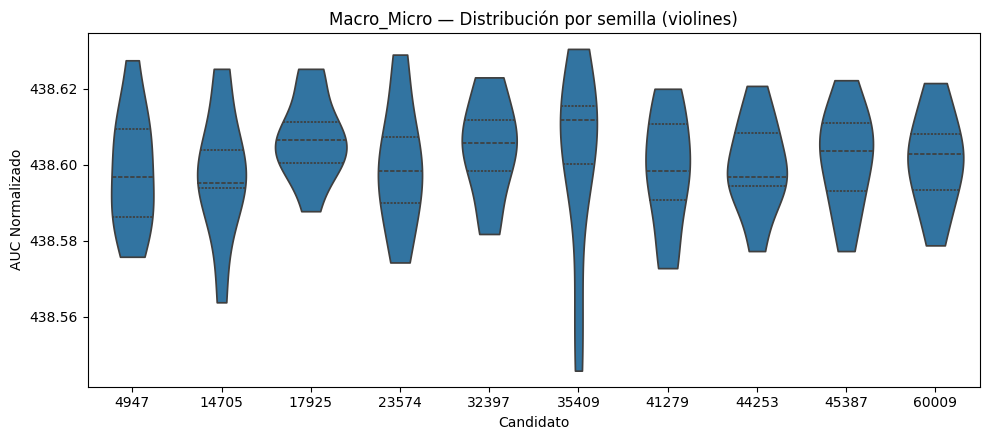

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

top10 = [17925, 32397, 45387, 60009, 44253, 23574, 4947, 41279, 14705, 35409]
subset = df_finetuning[df_finetuning["candidate_id"].isin(top10)]

plt.figure(figsize=(10,4.5))
sns.violinplot(data=subset, x="candidate_id", y="auc_best_norm",
               inner="quartile", cut=0)
plt.title("Macro_Micro — Distribución por semilla (violines)")
plt.xlabel("Candidato")
plt.ylabel("AUC Normalizado")
plt.tight_layout()
plt.show()

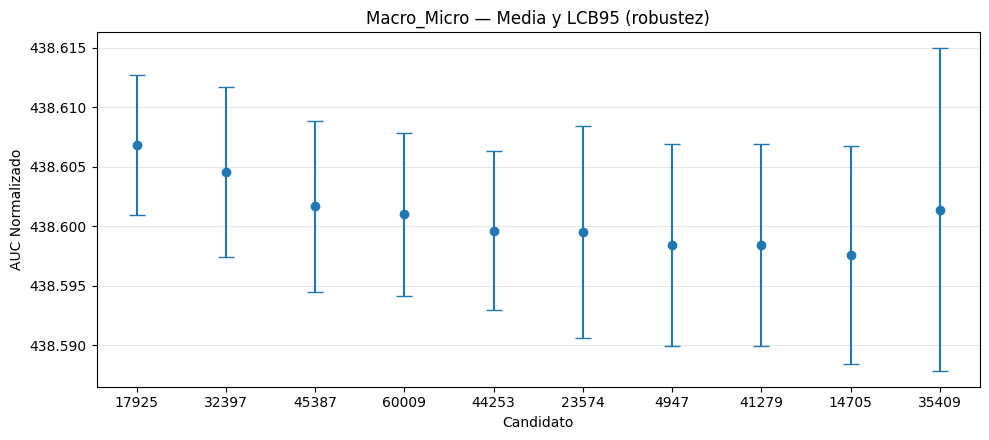

In [26]:
import numpy as np
import matplotlib.pyplot as plt

df_plot = df_lcb.loc[top10, ["auc_mean","lcb95"]].copy()
df_plot["yerr_down"] = df_plot["auc_mean"] - df_plot["lcb95"]

plt.figure(figsize=(10,4.5))
plt.errorbar(df_plot.index.astype(str),
             df_plot["auc_mean"],
             yerr=df_plot["yerr_down"],
             fmt='o', capsize=6)
plt.title("Macro_Micro — Media y LCB95 (robustez)")
plt.xlabel("Candidato")
plt.ylabel("AUC Normalizado")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

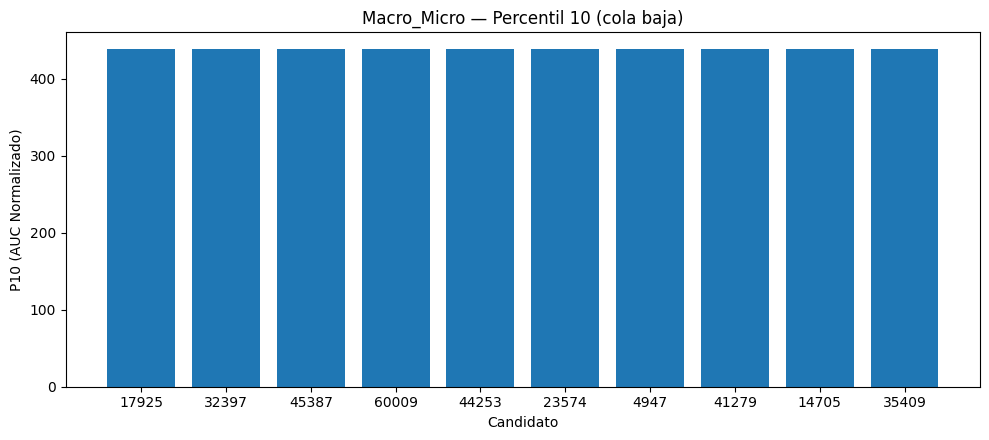

In [27]:
import matplotlib.pyplot as plt

p10_plot = df_lcb.loc[top10, "p10"]

plt.figure(figsize=(10,4.5))
plt.bar(p10_plot.index.astype(str), p10_plot.values)
plt.title("Macro_Micro — Percentil 10 (cola baja)")
plt.xlabel("Candidato")
plt.ylabel("P10 (AUC Normalizado)")
plt.tight_layout()
plt.show()


In [28]:
winner = 17925
report = (
    df_lcb.loc[top10, ["auc_mean","auc_std","n","se","lcb95","p10"]]
      .sort_values("lcb95", ascending=False)
)
print("WINNER (robustez):", winner)
display(report)

WINNER (robustez): 17925


,auc_mean,auc_std,n,se,lcb95,p10
candidate_id,,,,,,
17925,438.606841,0.010761,11,0.003245,438.600960,438.59825
32397,438.604523,0.013086,11,0.003946,438.597371,438.58625
45387,438.601659,0.013151,11,0.003965,438.594472,438.58775
60009,438.600977,0.012515,11,0.003773,438.594138,438.58775
44253,438.599614,0.012181,11,0.003673,438.592957,438.58700
23574,438.599477,0.016316,11,0.004919,438.590561,438.58025
4947,438.598386,0.015505,11,0.004675,438.589913,438.58325
41279,438.598386,0.015512,11,0.004677,438.589909,438.57575
14705,438.597568,0.016759,11,0.005053,438.588410,438.58025


In [ ]:
cid = 32397

params_32397 = (
    df_finetuning
    .loc[df_finetuning["candidate_id"] == cid, ["lambda_in","lambda_out","sel_mutation", "tail_mutation", "tourn_size"]]
    .iloc[0]
)

params_32397

lambda_in        0.100
lambda_out       0.700
sel_mutation     0.080
tail_mutation    0.065
tourn_size       5.000
Name: 242, dtype: float64